# 🗺️ Hermes: onde está o cliente da loja de bairro?

<img src="../app/assets/hermes.png" width="420" alt="Hermes, o mensageiro dos deuses">

*Hermes, deus grego do comércio, dos caminhos e dos viajantes.*

**Pergunta de negócio:** uma rede de mercados de proximidade tem 15 lojas em São Paulo e usa
**a mesma gôndola em todas**. Faz sentido? Quem mora e quem trabalha a **15 minutos a pé** de cada
loja, e **o que essas pessoas compram**?

**Resposta que o projeto entrega**, para cada loja:
1. a área **real** alcançável em 15 min a pé (seguindo as ruas, não um círculo);
2. o perfil de quem **mora** ali (idade, renda, nº de domicílios) e de quem **trabalha** ali;
3. o **potencial de gasto** com alimentos por categoria de gôndola (R$/mês);
4. um **índice de afinidade** (o que a vizinhança compra mais ou menos do que a média da cidade);
5. um **perfil de loja** (agrupamento) e uma **recomendação de mix** comparando potencial × vendas.

> **Sobre os dados.** Tudo o que descreve a cidade é **público e real** (IBGE, Metrô-SP,
> OpenStreetMap). A rede de lojas **"Ágora Express" é fictícia**, com pontos em bairros reais.
> As **vendas das lojas são sintéticas** (não existe base pública de vendas por loja), geradas só
> na última etapa, para demonstrar a análise de gap de sortimento.

*English summary: 15-minute walking catchments for a fictional São Paulo grocery chain, built from
real public data (2022 Census, 2023 Origin-Destination Survey, Household Budget Survey, OpenStreetMap),
turned into category-level spending potential, an affinity index vs. the city, store profiles
(k-means), and a product-mix recommendation against synthetic sales.*

## 0. As fontes de dados

| Fonte | Quem publica | O que tem | Para que usamos |
|---|---|---|---|
| **Censo Demográfico 2022**, agregados por setor censitário | IBGE | população, domicílios, idade e renda do responsável, para cada um dos ~27 mil setores da capital | **quem mora** perto da loja |
| **Pesquisa Origem-Destino 2023** (microdados) | Metrô-SP | ~30 mil domicílios entrevistados, com a coordenada do **local de trabalho** e o peso de expansão | **quem trabalha** perto da loja |
| **POF 2017-2018**, tabela SIDRA 6972 | IBGE | gasto médio mensal das famílias do estado de SP com cada tipo de alimento, por classe de renda | **o que** cada perfil compra |
| **IPCA**, tabela SIDRA 1737 | IBGE | inflação jan/2018 → jul/2022 | colocar renda e gasto na mesma moeda |
| **OpenStreetMap** (via `osmnx`) | comunidade OSM | ruas/calçadas e pontos de supermercados | área de 15 min e **concorrentes** |

Todos os links e a data de download ficam registrados em `dados/brutos/_origem.json` e aparecem na
aba **Dados e método** do app.

**Como rodar:** `rodar_pipeline.bat` baixa tudo e gera `dados/processados/`. Este notebook usa os
mesmos módulos (`src/hermes/`) e os arquivos já baixados, e explica cada etapa com os resultados
intermediários.

In [1]:
# --- Preparação -------------------------------------------------------------
import sys, json, warnings
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))          # para importar o pacote hermes
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from hermes import config, fontes, censo, od, pof, osm, analise, vendas, pipeline

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
AZUL, LARANJA, CINZA = "#2563c9", "#e0851f", "#9aa3ad"
print("pasta do projeto:", RAIZ)

pasta do projeto: /home/claude/hermes


## 1. As lojas (fictícias)

São 15 pontos escolhidos para ter **perfis bem diferentes**: centros financeiros (Faria Lima,
Paulista, Berrini), bairros residenciais consolidados (Perdizes, Vila Mariana, Mooca) e bairros
periféricos (Itaquera, Capão Redondo). As coordenadas são aproximadas e **não representam lojas reais**.

In [2]:
lojas = pipeline.lojas_gdf()
lojas[["loja_id", "nome", "lat", "lon"]]

,loja_id,nome,lat,lon
0,AG01,Faria Lima,-23.59,-46.68
1,AG02,Paulista,-23.56,-46.66
2,AG03,Largo da Batata,-23.57,-46.69
3,AG04,Vila Mariana,-23.59,-46.63
4,AG05,Mooca,-23.56,-46.60
5,AG06,Tatuapé,-23.54,-46.58
6,AG07,Santana,-23.50,-46.63
7,AG08,Berrini,-23.61,-46.70
8,AG09,República,-23.54,-46.64
9,AG10,Perdizes,-23.54,-46.68


## 2. A área de 15 minutos a pé (isócrona)

O jeito mais simples de definir a área de uma loja é um **círculo** de raio fixo. O problema é que
ninguém anda em linha reta: avenidas largas, rios, linhas de trem e quarteirões grandes mudam muito
o que dá para alcançar a pé.

Por isso usamos a **rede de caminhada do OpenStreetMap**, via `osmnx`:

1. baixamos o grafo de ruas/calçadas ao redor da loja. **Nós** são esquinas e **arestas** são
   trechos de rua, com o comprimento em metros;
2. achamos o nó mais próximo da loja;
3. `networkx.ego_graph(..., radius=1200, distance="length")` devolve **todos os nós a até 1.200 m
   de caminhada** (15 min × 4,8 km/h = 1.200 m);
4. transformamos os trechos alcançáveis num polígono (buffer de 30 m em volta das ruas + união).

Vamos ver o passo a passo na loja **AG01 · Faria Lima** (o pipeline guardou a rede dela).

In [3]:
import osmnx as ox
import networkx as nx
from shapely.geometry import Point

ARQ_GRAFO = config.DADOS_BRUTOS / "grafo_exemplo_AG01.graphml"
assert ARQ_GRAFO.exists(), "Rode o pipeline antes: ele salva a rede de ruas da AG01 aqui."
G = ox.load_graphml(ARQ_GRAFO)
print(f"rede de caminhada ao redor da loja: {G.number_of_nodes():,} nós (esquinas) e "
      f"{G.number_of_edges():,} arestas (trechos de rua)")

alcance = osm.distancia_caminhada_m()                       # 1.200 m
loja = lojas.set_index("loja_id").loc["AG01"]
ponto = gpd.GeoSeries([Point(loja.lon, loja.lat)], crs=config.CRS_WGS84).to_crs(config.CRS_METRICO).iloc[0]

origem = ox.distance.nearest_nodes(G, X=ponto.x, Y=ponto.y)   # esquina mais próxima da loja
sub = nx.ego_graph(G, origem, radius=alcance, distance="length")
print(f"alcançáveis em {alcance:,.0f} m de caminhada: {sub.number_of_nodes():,} nós")

# distância de caminhada de cada nó até a loja (para colorir o mapa)
dist = nx.single_source_dijkstra_path_length(G, origem, cutoff=alcance, weight="length")

rede de caminhada ao redor da loja: 2,164 nós (esquinas) e 6,340 arestas (trechos de rua)
alcançáveis em 1,200 m de caminhada: 853 nós


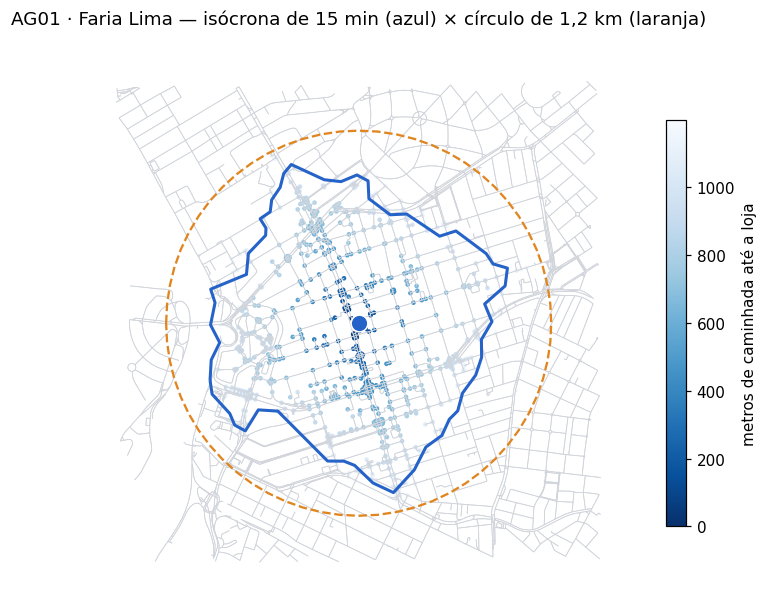

área do círculo: 4.52 km² · área da isócrona: 2.37 km² (52% do círculo)


In [4]:
isocronas_cache = gpd.read_file(config.DADOS_BRUTOS / "isocronas_cache.gpkg")
iso_ag01 = isocronas_cache.set_index("loja_id").loc["AG01", "geometry"]
circulo = ponto.buffer(alcance)          # o "jeito ingênuo": círculo de 1.200 m

nos, arestas = ox.graph_to_gdfs(G)
fig, ax = plt.subplots(figsize=(8, 8))
arestas.plot(ax=ax, color="#d1d5db", linewidth=0.5)
nos_alc = nos.loc[list(dist)].assign(d=pd.Series(dist))
nos_alc.plot(ax=ax, column="d", cmap="Blues_r", markersize=4, legend=True,
             legend_kwds={"label": "metros de caminhada até a loja", "shrink": 0.6})
gpd.GeoSeries([circulo]).boundary.plot(ax=ax, color=LARANJA, linestyle="--", linewidth=1.5)
gpd.GeoSeries([iso_ag01]).boundary.plot(ax=ax, color=AZUL, linewidth=2)
ax.scatter(ponto.x, ponto.y, s=120, color=AZUL, edgecolor="white", zorder=5)
ax.set_xlim(ponto.x - 1700, ponto.x + 1700); ax.set_ylim(ponto.y - 1700, ponto.y + 1700)
ax.set_axis_off()
ax.set_title("AG01 · Faria Lima — isócrona de 15 min (azul) × círculo de 1,2 km (laranja)")
plt.show()

print(f"área do círculo: {circulo.area/1e6:.2f} km² · área da isócrona: {iso_ag01.area/1e6:.2f} km² "
      f"({iso_ag01.area/circulo.area:.0%} do círculo)")

**Leitura:** na Faria Lima a área real é só **~metade do círculo** (52%). A caminhada segue as ruas,
e avenidas largas e quarteirões grandes "comem" alcance. Usar o círculo **superestimaria** a população
atendida e misturaria gente que, na prática, não vai a pé até a loja.

**Na prática, para ganhar velocidade**, o pipeline pede a isócrona pronta ao **Valhalla**, um motor de
rotas open source que roda sobre a mesma malha do OSM (~1 s por loja, contra minutos baixando o grafo
pelo Overpass). O cálculo acima com `osmnx` é o plano B e serve para mostrar o que acontece por
dentro. Se os dois falharem, a loja recebe um círculo de 920 m (1.200 m ÷ 1,3 de fator de
circuidade) e é refeita na próxima rodada. A coluna `metodo_area` registra o método de cada loja.

O pipeline repete isso para as 15 lojas e também consulta no OSM os **supermercados e lojas de
conveniência** dentro de cada área (`shop=supermarket` ou `shop=convenience`).

In [5]:
iso = isocronas_cache
conc = gpd.read_file(config.DADOS_BRUTOS / "concorrentes_cache.gpkg")
resumo_iso = iso.assign(area_km2=iso.area / 1e6).merge(lojas[["loja_id", "nome"]], on="loja_id")
resumo_iso["concorrentes"] = resumo_iso["loja_id"].map(conc.groupby("loja_id").size()).fillna(0)
# loja em que o OSM não respondeu: concorrentes DESCONHECIDOS (≠ zero)
resumo_iso.loc[~resumo_iso["concorrentes_ok"].astype(bool), "concorrentes"] = np.nan
resumo_iso[["loja_id", "nome", "metodo_area", "area_km2", "concorrentes"]].sort_values("area_km2")

,loja_id,nome,metodo_area,area_km2,concorrentes
1,AG02,Paulista,valhalla_osm,1.24,16.00
13,AG14,Capão Redondo,valhalla_osm,1.48,0.00
12,AG13,Itaquera,valhalla_osm,1.65,1.00
7,AG08,Berrini,valhalla_osm,1.80,9.00
9,AG10,Perdizes,valhalla_osm,1.90,13.00
6,AG07,Santana,valhalla_osm,2.29,NaN
5,AG06,Tatuapé,valhalla_osm,2.34,9.00
0,AG01,Faria Lima,valhalla_osm,2.37,4.00
14,AG15,Butantã,valhalla_osm,2.48,6.00
8,AG09,República,valhalla_osm,2.60,50.00


## 3. Quem mora perto: Censo 2022 por setor censitário

O **setor censitário** é o menor recorte que o IBGE publica, algo como um ou poucos quarteirões.
Juntamos três arquivos do Censo 2022:

- **malha com atributos**: o polígono de cada setor + população (`V0001`) e domicílios ocupados (`V0007`);
- **demografia**: população em 11 faixas de idade (`V01031` a `V01041`), que agrupamos em 0-14,
  15-29, 30-59 e 60+;
- **renda do responsável**: rendimento nominal médio mensal da pessoa responsável pelo domicílio.
  O código dessa variável é achado **lendo o dicionário de dados do IBGE**, e não fixado no código.

Cuidados com os arquivos do IBGE (tratados em `censo.py`): separador `;`, vírgula decimal, valores
sob sigilo marcados com `X` (viram vazio) e nomes de arquivo que mudam a cada republicação.

In [6]:
gpkg = fontes.baixar_malha_setores()
zip_demo, dic_ag = fontes.baixar_demografia()
zip_renda, dic_renda = fontes.baixar_renda()

setores, meta_censo = censo.montar_setores(gpkg, zip_demo, zip_renda, dic_ag, dic_renda)
print(f"{meta_censo['n_setores']:,} setores · {meta_censo['pop_total']:,.0f} moradores na capital")
print(f"{meta_censo['setores_sem_renda']:,} setores sem renda divulgada (sigilo ou sem domicílios)\n")
print("Variáveis usadas (descrição oficial do dicionário do IBGE):")
for cod, desc in meta_censo["variaveis"].items():
    print(f"  {cod}: {desc[:120]}")

  ✓ SP_setores_CD2022.gpkg já existe – pulando download
  ✓ censo_demografia.zip já existe – pulando download
  ✓ censo_agregados_dicionario.xlsx já existe – pulando download
  ✓ censo_renda.zip já existe – pulando download
  ✓ censo_renda_dicionario.xlsx já existe – pulando download


27,301 setores · 11,451,999 moradores na capital
629 setores sem renda divulgada (sigilo ou sem domicílios)

Variáveis usadas (descrição oficial do dicionário do IBGE):
  V0001: Total de pessoas
  V0005: Média de moradores em Domicílios Particulares Ocupados (Total pessoas em Domicílios Particulares Ocupados / DPPO + DPIO)
  V0007: Total de Domicílios Particulares Ocupados (DPPO + DPIO)
  V01031: 0 a 4 anos
  V01032: 5 a 9 anos
  V01033: 10 a 14 anos
  V01034: 15 a 19 anos
  V01035: 20 a 24 anos
  V01036: 25 a 29 anos
  V01037: 30 a 39 anos
  V01038: 40 a 49 anos
  V01039: 50 a 59 anos
  V01040: 60 a 69 anos
  V01041: 70 anos ou mais
  V06004: Valor do rendimento nominal médio mensal das pessoas responsáveis com rendimentos por domicílios particulares permanente


In [7]:
setores.drop(columns="geometry").describe().T[["count", "mean", "50%", "max"]]

,count,mean,50%,max
pop,"27,301.00",419.47,399.00,"2,221.00"
domicilios,"27,301.00",158.10,153.00,950.00
area_km2,"27,301.00",0.06,0.02,41.87
pop_0_14,"25,174.00",76.99,68.00,591.00
pop_15_29,"25,900.00",93.82,84.00,693.00
pop_30_59,"26,501.00",189.40,180.00,"1,056.00"
pop_60_mais,"25,872.00",77.90,72.00,299.00
renda_resp,"26,672.00","5,253.46","3,090.99","140,172.64"


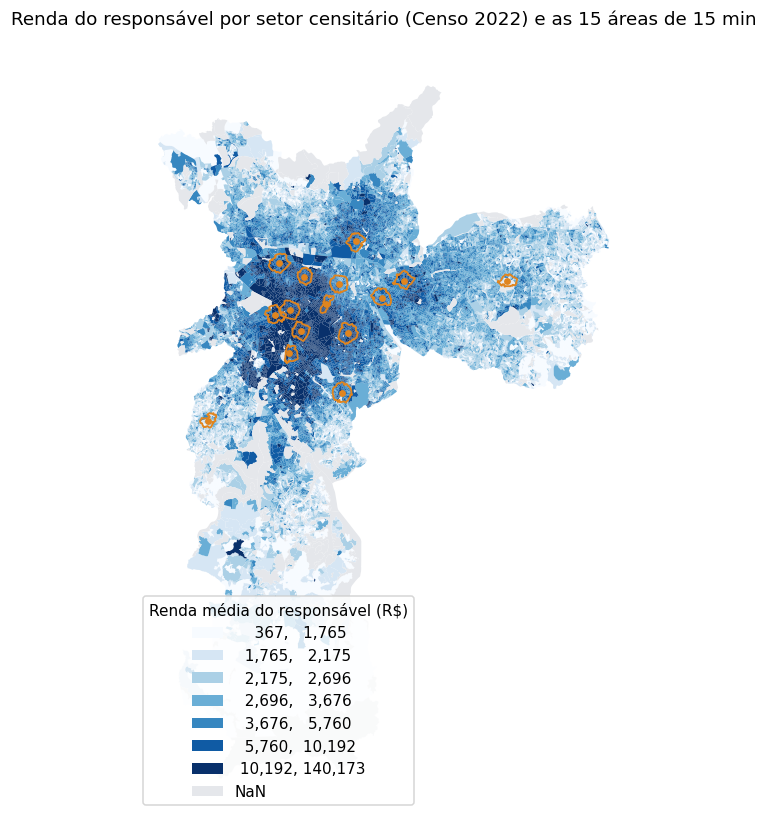

In [8]:
fig, ax = plt.subplots(figsize=(8, 9))
setores.plot(ax=ax, column="renda_resp", cmap="Blues", scheme="quantiles", k=7,
             legend=True, missing_kwds={"color": "#e5e7eb"},
             legend_kwds={"title": "Renda média do responsável (R$)", "fmt": "{:,.0f}", "loc": "lower left"})
iso.boundary.plot(ax=ax, color=LARANJA, linewidth=1.2)
lojas.to_crs(config.CRS_METRICO).plot(ax=ax, color=LARANJA, markersize=12)
ax.set_axis_off(); ax.set_title("Renda do responsável por setor censitário (Censo 2022) e as 15 áreas de 15 min")
plt.show()

O mapa mostra o conhecido **"centro rico, periferia pobre"** de São Paulo, com o eixo sudoeste
(Pinheiros, Itaim, Moema) concentrando as rendas mais altas. As áreas das lojas (em laranja) cobrem
esse gradiente todo, e é justamente isso que torna uma gôndola única pouco adequada.

## 4. Quem trabalha perto: Pesquisa Origem-Destino 2023

O Censo diz onde as pessoas **dormem**. Uma loja na Faria Lima, porém, vive de quem **trabalha** ali.
A Pesquisa OD do Metrô registra, para cada pessoa entrevistada, a **coordenada do local de trabalho**
e um **fator de expansão** (`FE_PESS`): quantas pessoas reais aquele entrevistado representa.

Filtros aplicados (em `od.py`):
- `F_PESS == 1`: o banco tem uma linha por **viagem**, e essa marca a primeira linha de cada pessoa;
- `SETOR1` preenchido: a pessoa trabalha;
- coordenadas de trabalho válidas (Córrego Alegre UTM 23S → convertidas para SIRGAS 2000).

In [9]:
trab = od.pontos_de_trabalho(fontes.baixar_od())
municipio = setores.union_all()
dentro = trab[trab.within(municipio)]
print(f"{len(trab):,} entrevistados com local de trabalho geolocalizado")
print(f"{dentro['peso'].sum():,.0f} empregos estimados no município (soma dos pesos)")

  ✓ pesquisa_od_2023.zip já existe – pulando download


39,533 entrevistados com local de trabalho geolocalizado
6,459,883 empregos estimados no município (soma dos pesos)


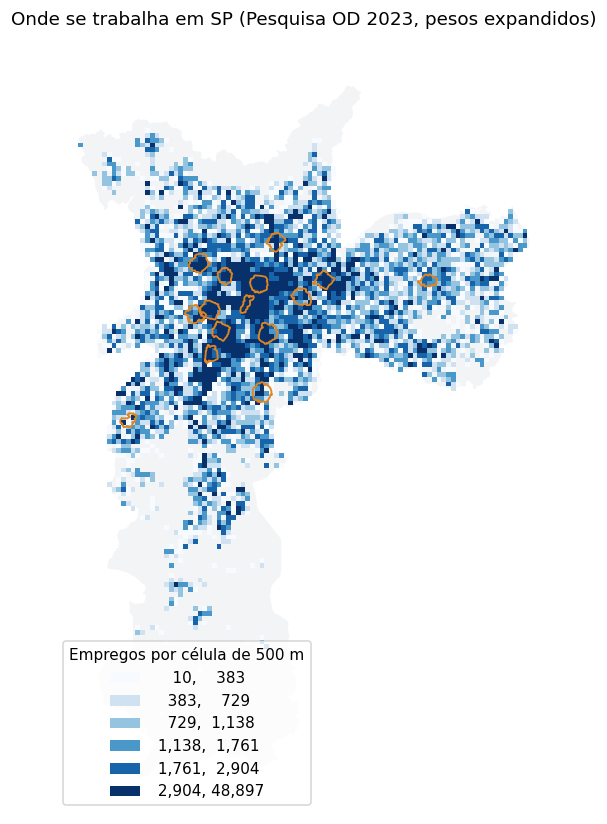

In [10]:
# Mapa de densidade de empregos: soma dos pesos numa grade de 500 m
from shapely.geometry import box
x0, y0, x1, y1 = municipio.bounds
grade = gpd.GeoDataFrame(geometry=[box(x, y, x + 500, y + 500)
                                   for x in np.arange(x0, x1, 500) for y in np.arange(y0, y1, 500)],
                         crs=config.CRS_METRICO)
grade = grade[grade.intersects(municipio)].reset_index(drop=True)
soma = gpd.sjoin(dentro, grade, predicate="within").groupby("index_right")["peso"].sum()
grade["empregos"] = soma
fig, ax = plt.subplots(figsize=(8, 9))
gpd.GeoSeries([municipio]).plot(ax=ax, color="#f3f4f6")
grade.dropna().plot(ax=ax, column="empregos", cmap="Blues", scheme="quantiles", k=6, legend=True,
                    legend_kwds={"title": "Empregos por célula de 500 m", "fmt": "{:,.0f}", "loc": "lower left"})
iso.boundary.plot(ax=ax, color=LARANJA, linewidth=1.2)
ax.set_axis_off(); ax.set_title("Onde se trabalha em SP (Pesquisa OD 2023, pesos expandidos)")
plt.show()

Os empregos se concentram muito mais que a moradia: centro, Paulista, Faria Lima e Berrini. Uma
loja nesses eixos tem um público diurno várias vezes maior que o residencial.

> ⚠️ A OD é **amostral**. Numa área de ~2 km², a soma dos pesos vem de algumas dezenas ou centenas de
> entrevistados, então o número de empregos é uma **estimativa com margem de erro**. Serve bem para
> separar "área de escritório" de "área residencial", mas não para cravar um número exato.

## 5. O que cada perfil compra: POF 2017-2018

A POF mede quanto as famílias gastam por mês com **cada tipo de alimento**. Pela API do SIDRA,
pegamos a tabela 6972 (estado de SP), cruzando **classe de renda familiar** × **tipo de despesa**.
Os ~20 itens da POF foram agrupados em **10 categorias de gôndola** (mapeamento em `config.py`):

In [11]:
for categoria, itens in config.CATEGORIAS_LOJA.items():
    print(f"{categoria:32s} ← itens SIDRA {', '.join(itens)}")

Mercearia básica                 ← itens SIDRA 103627, 103631, 103640, 103674, 103684, 103685
Hortifruti                       ← itens SIDRA 103636, 103644, 103649
Carnes e peixes                  ← itens SIDRA 103654
Aves e ovos                      ← itens SIDRA 103661
Laticínios e frios               ← itens SIDRA 103665
Padaria e biscoitos              ← itens SIDRA 103670
Café e bebidas não alcoólicas    ← itens SIDRA 103679, 103680, 8862, 8044
Bebidas alcoólicas               ← itens SIDRA 103681, 103682
Pronto para consumo              ← itens SIDRA 103690
Outros alimentos                 ← itens SIDRA 103691


In [12]:
itens_pof, pof_cat = pof.matriz_pof(fontes.baixar_pof())
rotulos = {c: r for c, r, *_ in config.CLASSES_POF} | {"7999": "Total"}
tabela = pof_cat.rename(index=rotulos)
tabela["TOTAL alimentação no domicílio"] = tabela.sum(axis=1)
print("Gasto médio mensal por FAMÍLIA, estado de SP, R$ de jan/2018:")
tabela.round(0)

  ✓ pof_6972_sp.json já existe – pulando consulta
Gasto médio mensal por FAMÍLIA, estado de SP, R$ de jan/2018:


,Mercearia básica,Hortifruti,Carnes e peixes,Aves e ovos,Laticínios e frios,Padaria e biscoitos,Café e bebidas não alcoólicas,Bebidas alcoólicas,Pronto para consumo,Outros alimentos,TOTAL alimentação no domicílio
classe,,,,,,,,,,,
até 1.908,46.00,25.00,42.00,16.00,29.00,26.00,15.00,4.00,6.00,38.00,247.00
1.908 a 2.862,53.00,27.00,57.00,18.00,34.00,34.00,22.00,8.00,11.00,35.00,299.00
2.862 a 5.724,77.00,44.00,82.00,26.00,46.00,47.00,34.00,13.00,18.00,54.00,441.00
5.724 a 9.540,97.00,64.00,115.00,29.00,65.00,58.00,46.00,21.00,28.00,36.00,558.00
9.540 a 14.310,134.00,104.00,121.00,37.00,96.00,75.00,66.00,33.00,39.00,53.00,759.00
14.310 a 23.850,154.00,118.00,138.00,47.00,117.00,99.00,77.00,35.00,68.00,75.00,928.00
mais de 23.850,188.00,128.00,162.00,47.00,114.00,78.00,75.00,65.00,81.00,106.00,"1,044.00"
Total,88.00,56.00,90.00,27.00,57.00,51.00,39.00,18.00,25.00,49.00,500.00


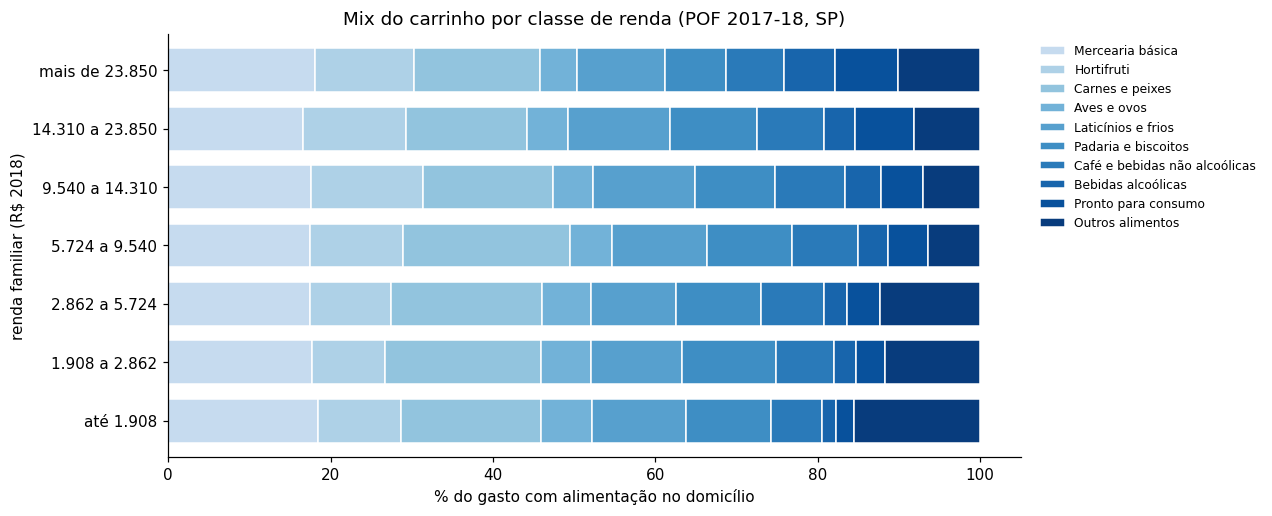

,Mercearia básica,Hortifruti,Carnes e peixes,Aves e ovos,Laticínios e frios,Padaria e biscoitos,Café e bebidas não alcoólicas,Bebidas alcoólicas,Pronto para consumo,Outros alimentos
classe,,,,,,,,,,
até 1.908,18.50,10.20,17.20,6.30,11.60,10.50,6.20,1.70,2.30,15.50
1.908 a 2.862,17.70,9.00,19.20,6.10,11.20,11.50,7.20,2.60,3.60,11.70
2.862 a 5.724,17.50,9.90,18.70,6.00,10.40,10.60,7.70,2.90,4.10,12.30
5.724 a 9.540,17.50,11.50,20.60,5.20,11.60,10.50,8.20,3.70,4.90,6.40
9.540 a 14.310,17.70,13.70,16.00,4.90,12.60,9.80,8.70,4.40,5.20,7.00
14.310 a 23.850,16.60,12.70,14.80,5.10,12.70,10.70,8.30,3.80,7.30,8.10
mais de 23.850,18.00,12.30,15.50,4.50,10.90,7.40,7.20,6.30,7.80,10.10


In [13]:
# O que muda no carrinho conforme a renda sobe? (peso de cada categoria no total)
mix = pof_cat.drop(index="7999", errors="ignore")
mix = mix.div(mix.sum(axis=1), axis=0).rename(index=rotulos) * 100
fig, ax = plt.subplots(figsize=(10, 5))
cores = plt.cm.Blues(np.linspace(0.25, 0.95, len(mix.columns)))
mix.plot(kind="barh", stacked=True, ax=ax, color=cores, edgecolor="white", linewidth=1, width=0.75)
ax.set_xlabel("% do gasto com alimentação no domicílio"); ax.set_ylabel("renda familiar (R$ 2018)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=8)
ax.set_title("Mix do carrinho por classe de renda (POF 2017-18, SP)")
plt.show()
mix.round(1)

É aqui que mora o valor do projeto: **a renda muda o mix, não só o tamanho do carrinho.** Famílias
de renda baixa concentram o gasto em mercearia básica, carnes e aves. Famílias de renda alta gastam
proporcionalmente mais com laticínios, hortifruti, bebidas e comida pronta.

**Da renda do Censo à classe da POF.** As duas fontes não "conversam" direto:
- o Censo traz a renda do **responsável** (jul/2022); a POF classifica pela renda da **família** (jan/2018);
- então fazemos `renda_familia_2018 = renda_resp × 1,5 ÷ IPCA(jul22/jan18)`.

O **1,5** é uma **premissa** (o responsável responde por ~2/3 da renda da casa) e fica explícita em
`config.PREMISSAS`. O IPCA vem do SIDRA.

In [14]:
fator = pof.fator_ipca(fontes.baixar_ipca())
print(f"IPCA acumulado jan/2018 → jul/2022: ×{fator:.3f} ({fator-1:.1%})")
setores = analise.adicionar_classe_pof(setores, fator)
(setores.groupby("classe_pof")["domicilios"].sum().rename(index=rotulos)
        .to_frame("domicílios na capital").assign(pct=lambda d: d.iloc[:, 0] / d.iloc[:, 0].sum() * 100))

  ✓ ipca_1737.json já existe – pulando consulta
IPCA acumulado jan/2018 → jul/2022: ×1.300 (30.0%)


,domicílios na capital,pct
classe_pof,,
até 1.908,411023,9.53
1.908 a 2.862,1231157,28.53
2.862 a 5.724,1408539,32.65
5.724 a 9.540,560189,12.98
9.540 a 14.310,361273,8.37
14.310 a 23.850,289285,6.70
mais de 23.850,53094,1.23


**Trabalhadores.** Quem trabalha perto não faz a compra do mês ali, mas compra lanche, salgado,
café e bebida. Usamos os itens de **alimentação fora de casa** da POF (sanduíches e salgados, lanches,
café, refrigerantes), divididos por trabalhadores por família (premissa 1,6). Como parte desse gasto
vai para padaria, café e restaurante, só 30% (premissa) conta como disputável pelo mercado.

In [15]:
gasto_trab = pof.gasto_trabalhador(itens_pof)
print("Gasto mensal por trabalhador disputável pelo mercado (R$ 2018):")
gasto_trab.round(2)

Gasto mensal por trabalhador disputável pelo mercado (R$ 2018):


Pronto para consumo             6.79
Café e bebidas não alcoólicas   2.32
dtype: float64

## 6. Juntando tudo: perfil de cada loja

**Interpolação por área.** Um setor pode estar só parcialmente dentro da isócrona. Assumimos que as
pessoas estão distribuídas uniformemente dentro do setor: se 40% da área do setor cai na isócrona,
contamos 40% dos moradores e domicílios dele. Como os setores são pequenos, o erro dessa hipótese
é baixo.

In [16]:
inter = analise.cruzar_setores(setores, iso)
print(f"{inter['CD_SETOR'].nunique():,} setores tocam alguma das 15 áreas")
inter[inter.loja_id == "AG01"][["CD_SETOR", "fracao", "pop", "domicilios", "renda_resp", "classe_pof"]].head(8)

1,737 setores tocam alguma das 15 áreas


,CD_SETOR,fracao,pop,domicilios,renda_resp,classe_pof
263,355030835000021,0.03,275,161,"14,625.23",47563
267,355030835000042,0.44,524,279,"13,507.76",47563
271,355030835000062,1.00,159,90,"12,178.38",47562
272,355030835000063,0.73,263,121,"10,214.25",47562
274,355030835000077,1.00,444,191,"22,214.10",47564
275,355030835000079,1.00,387,213,"29,192.11",47564
276,355030835000081,1.00,164,82,"16,871.39",47563
277,355030835000083,1.00,260,159,"17,126.04",47563


In [17]:
trab_lojas = gpd.sjoin(trab, iso[["loja_id", "geometry"]], predicate="within")
empregos = trab_lojas.groupby("loja_id")["peso"].sum()
n_conc = conc.groupby("loja_id").size()

perfil = analise.perfil_lojas(inter, iso, empregos, n_conc)
perfil = perfil.join(lojas.set_index("loja_id")["nome"])
perfil[["nome", "pop", "domicilios", "empregos", "empregos_por_morador", "renda_media_resp",
        "pct_0_14", "pct_60_mais", "densidade_hab_km2", "concorrentes"]].sort_values("renda_media_resp")

,nome,pop,domicilios,empregos,empregos_por_morador,renda_media_resp,pct_0_14,pct_60_mais,densidade_hab_km2,concorrentes
loja_id,,,,,,,,,,
AG14,Capão Redondo,"25,655.04","9,412.23","9,557.09",0.37,"2,236.04",0.19,0.15,"17,280.33",NaN
AG13,Itaquera,"10,930.24","3,856.40","11,227.18",1.03,"3,164.08",0.19,0.15,"6,628.54",1.00
AG09,República,"60,714.39","31,344.70","192,742.97",3.17,"5,818.86",0.10,0.18,"23,327.98",50.00
AG12,Jabaquara,"32,275.75","13,334.04","40,431.62",1.25,"6,231.86",0.12,0.25,"10,508.09",4.00
AG05,Mooca,"35,999.68","14,373.90","26,155.35",0.73,"7,490.87",0.14,0.23,"13,756.14",8.00
AG07,Santana,"17,650.53","7,454.72","39,543.35",2.24,"8,047.26",0.11,0.29,"7,717.92",NaN
AG06,Tatuapé,"24,071.92","10,483.59","49,065.93",2.04,"8,692.34",0.11,0.24,"10,271.99",9.00
AG11,Lapa,"25,028.53","10,512.34","59,859.17",2.39,"9,585.36",0.13,0.26,"8,651.73",11.00
AG15,Butantã,"6,474.16","2,742.61","29,068.20",4.49,"10,574.39",0.08,0.26,"2,613.26",6.00


## 7. Potencial de gasto por categoria e índice de afinidade

Para cada loja:

$$\text{potencial}_{cat} = \underbrace{\sum_{classes} \text{domicílios}_{classe} \times \text{gasto POF}_{classe,\,cat}}_{\text{moradores}} \;+\; \underbrace{\text{empregos} \times \text{gasto por trabalhador}_{cat}}_{\text{trabalhadores}}$$

tudo multiplicado pelo IPCA para ficar em **R$ de jul/2022**. Setores com renda sob sigilo têm seus
domicílios repartidos na mesma proporção de renda dos vizinhos da área.

O **índice de afinidade** compara o mix da área com o mix da cidade inteira:

$$\text{índice}_{cat} = \frac{\text{peso da categoria no potencial da área}}{\text{peso da categoria no potencial da cidade}} \times 100$$

Um índice **120** quer dizer que a vizinhança gasta, proporcionalmente, 20% a mais naquela categoria
que a média de SP. **Essa é a métrica que vai para a gôndola.**

In [18]:
dom_lojas = analise.domicilios_por_classe(inter, "loja_id")
pot = analise.potencial_categorias(dom_lojas, empregos, pof_cat, gasto_trab, fator)

dom_cidade = analise.domicilios_por_classe(setores.assign(loja_id="cidade"), "loja_id")
pot_cidade = analise.potencial_categorias(dom_cidade, pd.Series({"cidade": dentro["peso"].sum()}),
                                          pof_cat, gasto_trab, fator)
share_cidade = pot_cidade.set_index("categoria")["share"]
pot = analise.indice_afinidade(pot, share_cidade)

perfil["potencial_total_mes"] = pot.groupby("loja_id")["total"].sum()
print("Potencial total de gasto com alimentos por área (R$ milhões/mês, preços de jul/2022):")
(perfil["potencial_total_mes"] / 1e6).rename(index=perfil["nome"]).sort_values().round(1)

Potencial total de gasto com alimentos por área (R$ milhões/mês, preços de jul/2022):


loja_id
Itaquera           2.20
Butantã            2.90
Capão Redondo      4.10
Santana            6.70
Berrini            7.60
Tatuapé            9.70
Lapa              10.00
Jabaquara         10.20
Mooca             11.70
Faria Lima        12.90
Paulista          14.00
Largo da Batata   14.30
Perdizes          19.10
Vila Mariana      21.90
República         24.10
Name: potencial_total_mes, dtype: float64

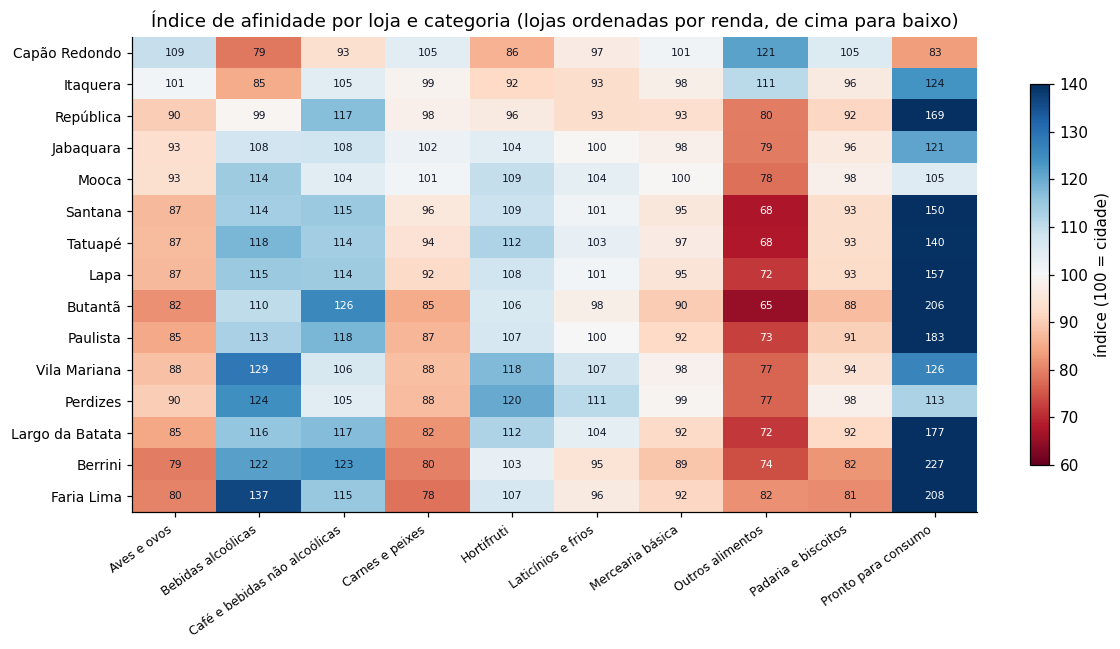

In [19]:
mat = pot.merge(lojas[["loja_id", "nome"]], on="loja_id").pivot_table(index="nome", columns="categoria", values="indice")
mat = mat.loc[perfil.sort_values("renda_media_resp")["nome"]]       # ordena da menor p/ maior renda
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(mat.values, cmap="RdBu", vmin=60, vmax=140, aspect="auto")
ax.set_xticks(range(mat.shape[1]), mat.columns, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(mat.shape[0]), mat.index, fontsize=9)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat.values[i, j]:.0f}", ha="center", va="center", fontsize=7,
                color="white" if abs(mat.values[i, j] - 100) > 25 else "#111827")
plt.colorbar(im, ax=ax, label="índice (100 = cidade)", shrink=0.8)
ax.set_title("Índice de afinidade por loja e categoria (lojas ordenadas por renda, de cima para baixo)")
plt.tight_layout(); plt.show()

**Como ler:** azul = a área compra **mais** que a média da cidade; vermelho = **menos**. Três coisas
saltam aos olhos:
- **Trabalhadores mandam no "pronto para consumo".** Berrini (227), Faria Lima (208) e Butantã (206)
  gastam o dobro da média da cidade nessa categoria, e *Café e bebidas* também sobe (115-126). É o
  público diurno comprando lanche.
- **A renda muda a borda do carrinho.** Nas áreas de renda alta sobem *bebidas alcoólicas*
  (Faria Lima 137, Vila Mariana 129), *hortifruti* e *laticínios* (Perdizes 120 e 111). Na periferia
  sobem *aves e ovos* (Capão Redondo 109), *carnes* e *padaria* (105), e bebida alcoólica cai (79).
- **A mercearia básica é quase igual em todo lugar (89-101).** Ela pode ser padrão na rede inteira:
  o que diferencia uma loja da outra são as categorias da borda.

## 8. Perfis de loja (k-means)

Para a rede não precisar de 15 planogramas diferentes, agrupamos as lojas em **4 perfis**. Variáveis
(padronizadas; empregos e densidade em log porque variam em ordens de grandeza): renda média,
% de crianças (0-14), % de idosos (60+), empregos por morador e densidade.

O k-means devolve só números (0, 1, 2, 3). Os **nomes** vêm do centro de cada grupo: o que mais se
destaca em empregos por morador vira "Corporativa", o de maior renda vira "Residencial de alta renda",
e assim por diante.

Por que k = 4? Com 15 lojas, mais grupos criariam clusters de 1-2 lojas, e para a operação 4
planogramas já é o limite prático. Conferimos a silhueta abaixo só como sanidade.

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

X = perfil[analise.VARS_CLUSTER].copy()
X["empregos_por_morador"] = np.log1p(X["empregos_por_morador"].fillna(0))
X["densidade_hab_km2"] = np.log1p(X["densidade_hab_km2"])
Z = StandardScaler().fit_transform(X.fillna(X.median()))
for k in range(2, 7):
    lab = KMeans(n_clusters=k, n_init=20, random_state=config.SEMENTE).fit_predict(Z)
    print(f"k={k}: silhueta {silhouette_score(Z, lab):.2f} · tamanhos {sorted(np.bincount(lab), reverse=True)}")

k=2: silhueta 0.44 · tamanhos [np.int64(13), np.int64(2)]
k=3: silhueta 0.31 · tamanhos [np.int64(9), np.int64(4), np.int64(2)]
k=4: silhueta 0.33 · tamanhos [np.int64(7), np.int64(4), np.int64(2), np.int64(2)]
k=5: silhueta 0.33 · tamanhos [np.int64(7), np.int64(3), np.int64(2), np.int64(2), np.int64(1)]
k=6: silhueta 0.29 · tamanhos [np.int64(5), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(1)]


In [21]:
perfil = analise.agrupar_lojas(perfil)
(perfil.groupby("perfil")
       .agg(lojas=("nome", lambda s: ", ".join(s)), renda=("renda_media_resp", "mean"),
            empregos_por_morador=("empregos_por_morador", "mean"), pct_0_14=("pct_0_14", "mean"),
            pct_60_mais=("pct_60_mais", "mean")))

,lojas,renda,empregos_por_morador,pct_0_14,pct_60_mais
perfil,,,,,
Corporativa (quem trabalha),"Faria Lima, Largo da Batata, Berrini, Butantã","14,533.43",4.95,0.10,0.24
Misto (mora e trabalha),"Paulista, República","8,256.60",3.74,0.09,0.21
Periferia familiar,"Itaquera, Capão Redondo","2,700.06",0.70,0.19,0.15
Residencial consolidado,"Vila Mariana, Mooca, Tatuapé, Santana, Perdize...","9,320.66",1.54,0.12,0.25


## 9. Da análise à gôndola: potencial × vendas (dados sintéticos)

⚠️ **A partir daqui os números de venda são inventados**, com semente fixa e reprodutíveis
(`vendas.py`). Simulamos a situação típica: a rede usa **o mesmo planograma em todas as lojas**
(o mix médio da cidade), então as vendas de cada loja ficam no meio do caminho entre o que a
vizinhança quer e o que a gôndola oferece:

$$\text{vendas}_{cat} = \text{captura} \times \text{potencial total} \times \big(0{,}55\cdot\text{mix local}_{cat} + 0{,}45\cdot\text{mix padrão}_{cat}\big) \times \text{sazonalidade} \times \text{ruído}$$

A captura cai com o número de concorrentes. Com dados reais, esta etapa seria substituída pelas
vendas da empresa.

**Regra de recomendação:** se o peso da categoria no **potencial** é ≥ 5% maior (relativo) que o
peso nas **vendas**, a recomendação é **Ampliar** o espaço; se é ≥ 5% menor, **Reduzir**. A
*oportunidade* em R$ é quanto a categoria venderia se o mix de vendas acompanhasse o potencial,
mantendo o faturamento total.

In [22]:
vend = vendas.gerar_vendas(pot, perfil, share_cidade)
gap = vendas.gap_sortimento(pot, vend)
print("Faturamento sintético médio mensal por loja (R$ mil):")
(vend.groupby("loja_id")["vendas"].sum() / 12 / 1e3).rename(index=perfil["nome"]).round(0).sort_values()

Faturamento sintético médio mensal por loja (R$ mil):


loja_id
Butantã           105.00
Itaquera          136.00
Capão Redondo     139.00
Largo da Batata   169.00
Santana           239.00
República         270.00
Berrini           282.00
Lapa              336.00
Paulista          347.00
Tatuapé           347.00
Mooca             420.00
Jabaquara         442.00
Perdizes          519.00
Vila Mariana      549.00
Faria Lima        640.00
Name: vendas, dtype: float64

In [23]:
def recomendacao(loja_id):
    g = gap[gap.loja_id == loja_id].sort_values("oportunidade_rs_mes", ascending=False)
    out = g[["categoria", "share", "share_vendas", "indice", "acao", "oportunidade_rs_mes"]].copy()
    out[["share", "share_vendas"]] *= 100
    return out.rename(columns={"share": "% potencial", "share_vendas": "% vendas",
                               "oportunidade_rs_mes": "oportunidade R$/mês"})

corp = perfil[perfil.perfil_chave == "corporativa"].index[0]
fam = perfil[perfil.perfil_chave == "familiar"].index[0] if (perfil.perfil_chave == "familiar").any() \
    else perfil.sort_values("renda_media_resp").index[0]
print(f"Loja de perfil corporativo: {corp} · {perfil.loc[corp, 'nome']}")
display(recomendacao(corp))
print(f"Loja de perfil familiar: {fam} · {perfil.loc[fam, 'nome']}")
display(recomendacao(fam))

Loja de perfil corporativo: AG01 · Faria Lima


,categoria,% potencial,% vendas,indice,acao,oportunidade R$/mês
8,Pronto para consumo,13.99,10.63,208.47,Ampliar,"21,524.39"
7,Bebidas alcoólicas,4.40,3.95,136.50,Ampliar,"2,866.90"
6,Café e bebidas não alcoólicas,9.57,9.13,115.20,Manter,"2,802.41"
1,Hortifruti,11.36,11.05,106.71,Manter,"1,971.01"
4,Laticínios e frios,10.72,10.88,96.47,Manter,"-1,012.85"
0,Mercearia básica,15.59,16.08,91.67,Manter,"-3,139.45"
3,Aves e ovos,4.34,4.86,80.05,Reduzir,"-3,331.59"
9,Outros alimentos,8.01,8.69,81.65,Reduzir,"-4,386.88"
5,Padaria e biscoitos,8.30,9.10,81.01,Reduzir,"-5,098.22"
2,Carnes e peixes,13.72,15.62,78.32,Reduzir,"-12,195.71"


Loja de perfil familiar: AG13 · Itaquera


,categoria,% potencial,% vendas,indice,acao,oportunidade R$/mês
128,Pronto para consumo,8.31,7.44,123.79,Ampliar,"1,177.05"
129,Outros alimentos,10.87,10.17,110.89,Ampliar,957.82
125,Padaria e biscoitos,9.89,9.65,96.50,Manter,334.50
123,Aves e ovos,5.49,5.33,101.08,Manter,213.87
126,Café e bebidas não alcoólicas,8.69,8.81,104.59,Manter,-159.10
122,Carnes e peixes,17.28,17.45,98.65,Manter,-235.90
121,Hortifruti,9.79,9.98,91.93,Manter,-259.51
127,Bebidas alcoólicas,2.74,3.05,85.10,Reduzir,-420.11
124,Laticínios e frios,10.34,10.91,93.08,Reduzir,-770.02
120,Mercearia básica,16.60,17.22,97.64,Manter,-838.59


## 10. Conclusões

1. **A área real de 15 min é bem menor que o círculo equivalente** (1,2 a 3,1 km², contra 4,5 km² do
   círculo de 1,2 km). Definir a área pelo círculo superestima o público e mistura bairros que não
   conversam a pé.
2. **Duas forças definem o mix:** a **renda** de quem mora (muda a composição do carrinho) e o
   **volume de trabalhadores**. Nas lojas de escritório há 4 a 5 empregos por morador, e o
   *pronto para consumo* chega a 2x a média da cidade.
3. **Uma gôndola só não serve para a rede toda, mas o miolo pode ser igual.** A mercearia básica
   varia pouco; a diferença está nas bordas (lanche, bebidas, hortifruti, proteínas). Com 4 perfis
   dá para ter 4 planogramas de borda sobre um miolo comum, sem a complexidade de 15 layouts.
4. **O índice de afinidade é a ponte para a operação:** ele fala a língua do comercial ("essa loja
   vende 30% mais café que a média") e pode ser recalculado para qualquer ponto candidato a loja nova.

## 11. Limitações (honestas)

- **Potencial ≠ venda:** é o que a vizinhança gasta com alimentos para casa, em qualquer lugar.
- **POF de 2017-18 e estadual:** hábitos mudaram (delivery, pós-pandemia) e o recorte é o estado,
  não o bairro. Duas áreas de mesma renda recebem o mesmo carrinho.
- **Premissas** (renda familiar = 1,5 × a do responsável; 1,6 trabalhador por família; 30% do lanche
  disputável) estão todas em `config.PREMISSAS`; mudar e rodar de novo é trivial.
- **OD amostral** e **OSM colaborativo:** empregos têm margem de erro e a lista de concorrentes pode
  estar incompleta. A Faria Lima, por exemplo, tem só 4 mercados mapeados no OSM, com certeza menos
  que a realidade. Uma loja (Santana) ficou sem concorrentes porque o OSM não respondeu, e nela
  usamos a mediana das outras.
- **Vendas sintéticas:** a etapa de gap é uma demonstração do método.

## 12. Próximos passos

- Substituir as vendas sintéticas pelas reais e **validar** o potencial (correlação índice × vendas).
- Usar o mesmo pipeline para **escolher pontos novos** (varrer candidatos numa grade H3).
- Trocar a POF por dados de cartão ou de ticket de clientes (mais atuais e locais).
- Isócronas por horário (almoço × noite) e por modo (a pé × bicicleta × carro).